# Template matching

In [1]:
import cv2
from matplotlib import pyplot as plt

plt.gray()

<Figure size 432x288 with 0 Axes>

The goal of template matching is to find the location of a template image in a larger image. Thus to perform template matching, or block matching, we initially need an image containing some feature (e.g. an object) to locate.
For this exercise we will be using one of the images of a playtable and for simplicity we will be focusing on single channel images (grayscale images).

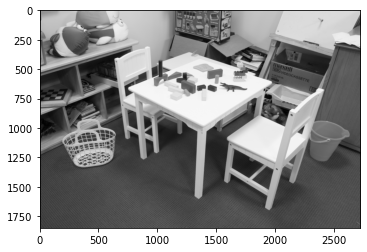

In [8]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 3/"
img = cv2.imread(path + "playtable_left.png")

# Convert to RGB for matplotlib display, then to Grayscale for processing
img_left = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray_left = cv2.cvtColor(img_left, cv2.COLOR_RGB2GRAY)

plt.imshow(gray_left)

The second thing we need is a template containing the features or object that we are interested in locating.

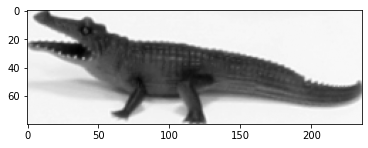

In [9]:
template = cv2.imread(path + 'crocodile.png')

# Though the template is saved as a single channel (grayscale) image, it is loaded as a 3 channel image with identical channels.
# Therefore we can just take any of the three channels.
# template[..., 0] grabs the first channel (Blue in BGR). Since R=G=B in a grayscale image, this is fine.
template = template[...,0]
plt.imshow(template)

With both an image and a template, we can perform template matching to locate the crocodile in the large playtable image.

## Exercise 1.1
We will use a normalized cross correlation as a similarity metric defined [here](https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html#ga3a7850640f1fe1f58fe91a2d7583695d).

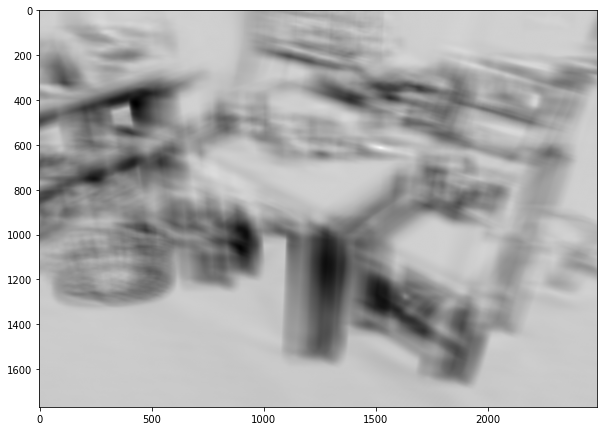

In [ ]:
# Perform Template Matching
# cv2.matchTemplate(image, templ, method)
# image - Image where the search is running. It must be 8-bit or 32-bit floating-point.
# templ - Searched template. It must be not greater than the source image and have the same data type.
# method - Specifies the comparison method.
# cv2.TM_CCORR_NORMED (Normalized Cross-Correlation):
# It calculates the correlation between the template and the image patch.
# Because it is normalized, the result is between 0 and 1.
# 1 means a perfect match, 0 means no correlation.
res = cv2.matchTemplate(gray_left, template, cv2.TM_CCORR_NORMED)
plt.figure(figsize = (10,10))
plt.imshow(res, 'gray')

What does the above image tell us?

We can use the minMaxLoc() function to find the location which best matches our template and draw a rectangle around it. 

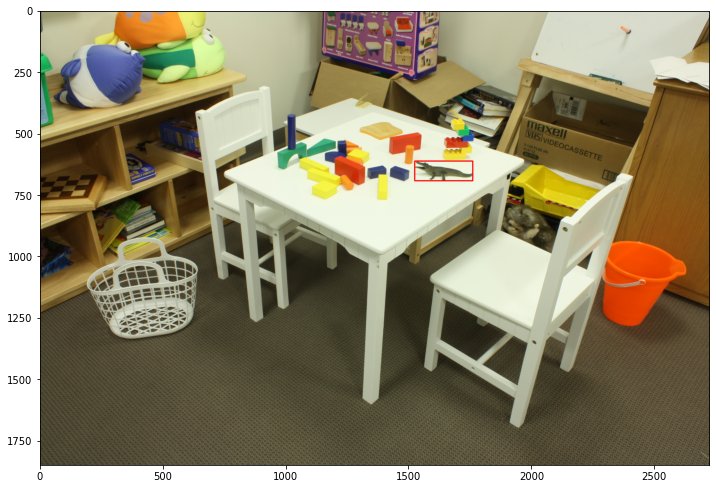

In [ ]:
# Find the global minimum and maximum in the result matrix
# min_val, max_val - The lowest and highest values in the matrix
# min_loc, max_loc - The (x, y) coordinates of those values
# Since we used Cross-Correlation (TM_CCORR_NORMED), the *highest* value represents the best match.
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

# The top-left corner of the matching rectangle is the location of the maximum correlation
top_left = max_loc

# Calculate the bottom-right corner
# We add the width (shape[1]) and height (shape[0]) of the template to the top-left coordinates.
bottom_right = (top_left[0] + template.shape[1], top_left[1] + template.shape[0])

# Draw a blue rectangle around the detected object on a copy of the original image
crocodile = cv2.rectangle(img_left.copy(), top_left, bottom_right, (255,0,0), 3)

plt.figure(figsize=(12,12))
plt.imshow(crocodile)

## Exercise 1.2
Use template matching to locate the orange bucket in the center-right side of `playtable_left.png`

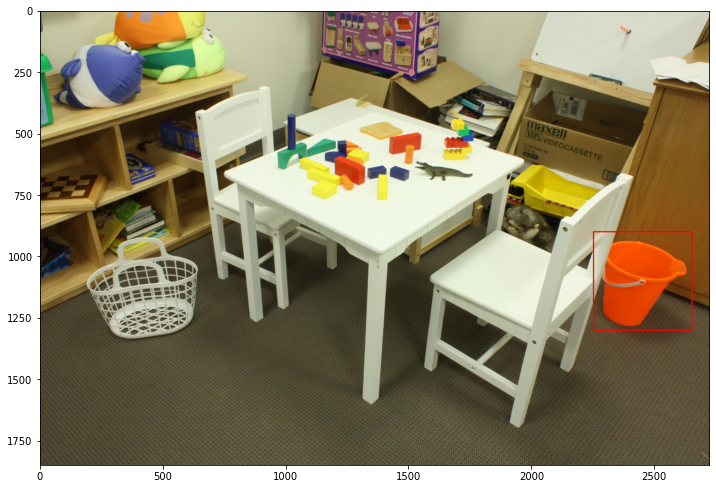

In [10]:
# Manually crop a region from the image to use as a new template (the orange bucket).
# Slicing is done as [y_start:y_end, x_start:x_end].
sample = gray_left[900:1300, 2250:2650]

# Perform matching again using the new template
res_bucket = cv2.matchTemplate(gray_left, sample, cv2.TM_CCORR_NORMED)

# Locate the best match (highest correlation)
min_val_bucket, max_val_bucket, min_loc_bucket, max_loc_bucket = cv2.minMaxLoc(res_bucket)

top_left_bucket = max_loc_bucket
bottom_right_bucket = (top_left_bucket[0] + sample.shape[1], top_left_bucket[1] + sample.shape[0])

# Draw the rectangle
bucket = cv2.rectangle(img_left.copy(), top_left_bucket, bottom_right_bucket, (255,0,0), 3)

plt.figure(figsize=(12,12))
plt.imshow(bucket)

## Exercise 1.3
In the above examples, we used normalized cross correlation as the metric to create our similarity map. You can find the mathematical description [here](https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html#ga3a7850640f1fe1f58fe91a2d7583695d). In the same link you will also find other similarity metrics.

Try to use the squared difference `cv2.TM_SQDIFF` instead and compare it to the above result.

**Hint:** plot the results next to each other.

**NOTE:** Based on the definitions in the above link, we see that `cv2.TM_SQDIFF` gives a low value for a good match, i.e. we have to look for the lowest value in the similarity map instead of the maximum value like we did with `cv2.TM_CCORR_NORMED`.

Text(0.5, 1.0, 'Squared Difference')

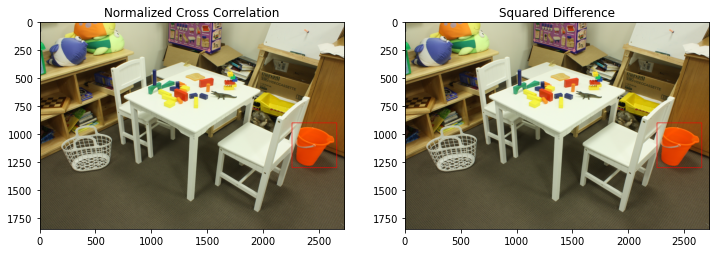

In [11]:
# Perform matching using Squared Difference (TM_SQDIFF)
# In this method, the algorithm calculates the squared difference between pixels.
# If the template and the image patch are identical, the difference is 0.
# Therefore, smaller values indicate a better match.
res_bucket2 = cv2.matchTemplate(gray_left, sample, cv2.TM_SQDIFF)

min_val_bucket2, max_val_bucket2, min_loc_bucket2, max_loc_bucket2 = cv2.minMaxLoc(res_bucket2)

# Important: We use min_loc_bucket2 here because TM_SQDIFF looks for the minimum value (0 is perfect match)
# Unlike the previous exercise where we used max_loc because TM_CCORR looks for the maximum value (1 is perfect match)
top_left_bucket2 = min_loc_bucket2
bottom_right_bucket2 = (top_left_bucket2[0] + sample.shape[1], top_left_bucket2[1] + sample.shape[0])

bucket2 = cv2.rectangle(img_left.copy(), top_left_bucket2, bottom_right_bucket2, (255,0,0), 3)

# Display the comparison side-by-side
plt.figure(figsize=(12,12))
plt.subplot(1, 2, 1)
plt.imshow(bucket)
plt.title('Normalized Cross Correlation') # Looks for Max
plt.subplot(1, 2, 2)
plt.imshow(bucket2)
plt.title('Squared Difference') # Looks for Min